# ActionStyle v3: training-data ablation of v2

Run from `notebooks/effective-gzsda/gzsda/` using the `asad` kernel.
This notebook keeps the v2 method order, model settings, seven leave-one-style-out pairs,
512-dimensional features, `NUM_LABELS = 5`, and six original trials. Run all cells to
train every v2 method separately with **25%, 50%, and 75%** of the original training data.

Both source training (all rows of `all_but_*`, as used by v2) and labeled target seen
training (`splitFlag == 1`) are reduced per action class. Sampling uses a fixed seed,
independent of model RNG, and nested subsets: 25% ⊂ 50% ⊂ 75% ⊂ 100%. Source subsets
are fixed across trials, as in v2; target subsets follow each trial's original training
split. Class-wise counts use floor rounding with at least one sample per available
class; the actual counts are exported. **Target test samples, unseen classes, and all
original v2 files stay unchanged**; discarded target training samples get flag 0.

Derived `.mat` files and index manifests live in the ignored
`data/ActionStyleDataset_v2/ablation_v3/train_{25,50,75}/` directories, so all methods
(including TUPL, VAE→TUPL, and VisTA) consume exactly the same subsets.

All percentages share one results JSON (`result/json/actionStyle_v3.json`) and one
final results CSV (`result/csv/actionStyle_v3.csv`). Experiment names include the
percentage: `all_but_angry_25 -> angry`, `all_but_angry_50 -> angry`, and
`all_but_angry_75 -> angry`, with the same naming for every style. Saved v2 results
are loaded by the `import-v2-reference` cell near the start, before data preparation
or training, and saved immediately as the 100% reference (`all_but_angry_100 -> angry`). Timing reports
(`raw_time_actionStyle_v3.json`, `result_time_actionStyle_v3.csv`) also combine all
percentages and list the experiment names covered by each whole-grid timing.
`actionStyle_v3_train_counts.csv` uses the same source names for actual sample counts.

Completed methods are skipped and new results are saved immediately after each method.
Earlier separate percentage files are read for migration only; no new percentage
report files are written. These experiments measure the effect of data quantity;
improvement is an empirical result, not an assumption.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np

from src.utils import (
    get_args,
    set_seed,
    get_datesets_and_loaders,
    get_trained_VAE,
    get_trained_VAE_with_domain_classifier,
    get_trained_classifier,
    get_trained_classifier_Base,
    test_model,
    prepare_report,
    run_all_senario,
)
from src.tupl import DATASET_CONFIGS, run_tupl
from src.our_tupl import GENERATION_POLICIES, run_m1_tupl, run_all_senario_m1_tupl
from src.vista_gzsda import run_vista
from src.utils_report import METHOD_ORDER, results_to_dataframe, times_to_dataframe

/home/asad/workspace/DomainProject/changeDomain/notebooks/effective-gzsda/gzsda/src/utils.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  import scipy
/home/asad/workspace/anaconda3/envs/asad/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path

STYLE_LABELS = [
    "angry", "childlike", "depressed", "neutral",
    "old", "proud", "strutting",
]
DOMAIN_SET = [f"all_but_{s}" for s in STYLE_LABELS] + STYLE_LABELS
PAIRS = [(i, i + len(STYLE_LABELS)) for i in range(len(STYLE_LABELS))]
V2_DATA_DIR = Path("./data/ActionStyleDataset_v2/")
V3_DATA_ROOT = V2_DATA_DIR / "ablation_v3"
TRAIN_PERCENTAGES = (25, 50, 75)
SUBSAMPLE_SEED = 1
NUM_TRIALS = 6
DATASET_DETAILS = {
    "prefix": "ActionStyle-",
    "suffix": "-clip.mat",
    "resnet_feature": "clip_features",
    "split_file_name": "instanceSplit_actionStyle_v2_unseen2.mat",
}
NUM_LABELS = 5

print("DOMAIN_SET", DOMAIN_SET)
print("PAIRS", [(DOMAIN_SET[s], DOMAIN_SET[t]) for s, t in PAIRS])

DOMAIN_SET ['all_but_angry', 'all_but_childlike', 'all_but_depressed', 'all_but_neutral', 'all_but_old', 'all_but_proud', 'all_but_strutting', 'angry', 'childlike', 'depressed', 'neutral', 'old', 'proud', 'strutting']
PAIRS [('all_but_angry', 'angry'), ('all_but_childlike', 'childlike'), ('all_but_depressed', 'depressed'), ('all_but_neutral', 'neutral'), ('all_but_old', 'old'), ('all_but_proud', 'proud'), ('all_but_strutting', 'strutting')]


In [4]:
import json
import time
from pathlib import Path

RESULT_OBJ_PATH = "./result/json/actionStyle_v3.json"
RESULT_CSV_PATH = "./result/csv/actionStyle_v3.csv"
RESULT_TIME_PATH = "./result/times/raw_time_actionStyle_v3.json"
RESULT_TIME_CSV_PATH = "./result/times/result_time_actionStyle_v3.csv"


def scenario_with_percentage(scenario, percent):
    source, target = scenario.split(" -> ", 1)
    suffix = f"_{percent}"
    if not source.endswith(suffix):
        source += suffix
    return f"{source} -> {target}"


def percentage_scenarios(percent):
    return [
        scenario_with_percentage(f"{DOMAIN_SET[s]} -> {DOMAIN_SET[t]}", percent)
        for s, t in PAIRS
    ]


def read_json(path):
    path = Path(path)
    return json.loads(path.read_text()) if path.exists() else {}


# Match v2's method -> scenario -> report structure, with all percentages together.
result_store = read_json(RESULT_OBJ_PATH)
time_store = read_json(RESULT_TIME_PATH)
results_by_percent = {}
times_by_percent = {}

for percent in TRAIN_PERCENTAGES:
    expected = set(percentage_scenarios(percent))
    values = {
        method: {scenario: report for scenario, report in scenarios.items() if scenario in expected}
        for method, scenarios in result_store.items()
    }
    values = {method: scenarios for method, scenarios in values.items() if scenarios}
    # Import earlier separate files as input only; new runs never write them.
    legacy = read_json(f"./result/json/actionStyle_v3_train_{percent}.json")
    for method, scenarios in legacy.items():
        for scenario, report in scenarios.items():
            values.setdefault(method, {}).setdefault(scenario_with_percentage(scenario, percent), report)
    results_by_percent[percent] = values

    times = {
        method: entries[str(percent)]["total_time"]
        for method, entries in time_store.items() if str(percent) in entries
    }
    legacy_times = read_json(f"./result/times/raw_time_actionStyle_v3_train_{percent}.json")
    for method, total_time in legacy_times.items():
        times.setdefault(method, total_time)
    times_by_percent[percent] = times

# Filled by the following cell, before data preparation or training.
reference_results = {}
reference_times = {}


def activate_percentage(percent):
    global DATA_DIR, TUPL_DATASET, result, result_time

    DATA_DIR = str(V3_DATA_ROOT / f"train_{percent}") + "/"
    TUPL_DATASET = f"actionstyle_v3_train_{percent}"
    result = results_by_percent[percent]
    result_time = times_by_percent[percent]


def save_results():
    for percent, values in [*results_by_percent.items(), (100, reference_results)]:
        for method, scenarios in values.items():
            labeled = {
                scenario_with_percentage(scenario, percent): report
                for scenario, report in scenarios.items()
            }
            result_store.setdefault(method, {}).update(labeled)

    for percent, values in [*times_by_percent.items(), (100, reference_times)]:
        for method, total_time in values.items():
            # These are whole-grid timings, so list all covered experiments.
            # Do not invent per-scenario timings from the aggregate elapsed time.
            time_store.setdefault(method, {})[str(percent)] = {
                "experiments": percentage_scenarios(percent),
                "n_senario": len(PAIRS),
                "n_trial": NUM_TRIALS,
                "total_trial": len(PAIRS) * NUM_TRIALS,
                "total_time": total_time,
            }

    for output_path, values in [(RESULT_OBJ_PATH, result_store), (RESULT_TIME_PATH, time_store)]:
        path = Path(output_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(values, indent=2), encoding="utf-8")


for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    print(f"{percent}%", list(result), list(result_time))


25% ['base', 'CCVAE', 'our0', 'our_GRE', 'TUPL', 'our_TUPL_real_plus_src2tgt', 'our_TUPL_real_plus_src2tgt_unseen', 'our_TUPL_interp_src2tgt'] ['base', 'CCVAE', 'our0', 'our_GRE', 'TUPL', 'our_TUPL_real_plus_src2tgt', 'our_TUPL_real_plus_src2tgt_unseen', 'our_TUPL_interp_src2tgt']
50% ['base', 'CCVAE', 'our0', 'our_GRE', 'TUPL', 'our_TUPL_real_plus_src2tgt', 'our_TUPL_real_plus_src2tgt_unseen'] ['base', 'CCVAE', 'our0', 'our_GRE', 'TUPL', 'our_TUPL_real_plus_src2tgt', 'our_TUPL_real_plus_src2tgt_unseen']
75% ['base', 'CCVAE', 'our0', 'our_GRE', 'TUPL'] ['base', 'CCVAE', 'our0', 'our_GRE', 'TUPL']


In [5]:
# Import the 100% reference from saved v2 results before any v3 training.
V2_RESULT_OBJ_PATH = "./result/json/actionStyle_v2.json"
V2_RESULT_TIME_PATH = "./result/times/raw_time_actionStyle_v2.json"

v2_results = read_json(V2_RESULT_OBJ_PATH)
reference_results = {
    method: {
        scenario_with_percentage(scenario, 100): report
        for scenario, report in scenarios.items()
    }
    for method, scenarios in v2_results.items()
}
reference_times = read_json(V2_RESULT_TIME_PATH)

# Merge into the shared v3 results and write both JSON reports immediately.
save_results()
print(
    f"Imported {sum(len(scenarios) for scenarios in reference_results.values())} "
    f"100% reference reports from v2 ({len(reference_results)} methods)."
)


Imported 63 100% reference reports from v2 (9 methods).


In [6]:
import copy
import hashlib
import json
import scipy.io
import pandas as pd


def stratified_train_indices(labels, candidates, percent, seed_parts):
    """Use prefixes of fixed class-wise permutations: 25% ⊂ 50% ⊂ 75%."""
    labels = np.asarray(labels).ravel()
    candidates = np.asarray(candidates, dtype=np.int64)
    rng = np.random.default_rng(np.random.SeedSequence(seed_parts))
    selected = []
    for label in np.unique(labels[candidates]):
        indices = candidates[labels[candidates] == label]
        # Integer rounding; retain at least one sample of every available class.
        count = max(1, len(indices) * percent // 100)
        selected.extend(rng.permutation(indices)[:count].tolist())
    return np.sort(np.asarray(selected, dtype=np.int64))


def prepare_training_subsets():
    """Materialize reduced v2 training data for every loader, including TUPL."""
    filenames = [
        f"{DATASET_DETAILS['prefix']}{domain}{DATASET_DETAILS['suffix']}"
        for domain in DOMAIN_SET
    ]
    split_name = DATASET_DETAILS["split_file_name"]
    # Fingerprints keep resumed results tied to the same original data and seed.
    fingerprints = {
        name: hashlib.sha256((V2_DATA_DIR / name).read_bytes()).hexdigest()
        for name in [*filenames, split_name]
    }
    original_data = [scipy.io.loadmat(V2_DATA_DIR / name) for name in filenames]
    original_split = scipy.io.loadmat(V2_DATA_DIR / split_name)
    assert original_split["targetDomain_splitFlag"].shape == (1, NUM_TRIALS)
    feature_key = DATASET_DETAILS["resnet_feature"]
    count_rows = []

    for percent in TRAIN_PERCENTAGES:
        output_dir = V3_DATA_ROOT / f"train_{percent}"
        manifest_path = output_dir / "subset_manifest.json"
        manifest = {
            "version": 1,
            "train_percent": percent,
            "seed": SUBSAMPLE_SEED,
            "v2_sha256": fingerprints,
            "source_indices": {},
            "target_train_indices": {},
        }
        reduced_split = {
            k: copy.deepcopy(v) for k, v in original_split.items()
            if not k.startswith("__")
        }
        reduced_data = []

        for domain_index, (domain, data) in enumerate(zip(DOMAIN_SET, original_data)):
            labels = data["labels"].ravel()
            if domain_index < len(STYLE_LABELS):
                # v2 uses ALL rows of all_but_* as source training, regardless of flags.
                indices = stratified_train_indices(
                    labels, np.arange(len(labels)), percent,
                    [SUBSAMPLE_SEED, 0, domain_index],
                )
                manifest["source_indices"][domain] = indices.tolist()
                reduced_data.append({
                    "labels": data["labels"][:, indices],
                    feature_key: data[feature_key][indices],
                })
                for trial in range(NUM_TRIALS):
                    reduced_split["targetDomain_splitFlag"][0, trial][0, domain_index] = (
                        original_split["targetDomain_splitFlag"][0, trial][0, domain_index][:, indices]
                    )
            else:
                # Keep target features/labels intact; only flag=1 samples may be removed.
                reduced_data.append({k: v for k, v in data.items() if not k.startswith("__")})
                for trial in range(NUM_TRIALS):
                    original_flags = original_split["targetDomain_splitFlag"][0, trial][0, domain_index]
                    flags = original_flags.copy()
                    candidates = np.flatnonzero(original_flags.ravel() == 1)
                    indices = stratified_train_indices(
                        labels, candidates, percent,
                        [SUBSAMPLE_SEED, 1, domain_index, trial],
                    )
                    flags[original_flags == 1] = 0
                    flags[0, indices] = 1
                    assert np.array_equal(flags == 2, original_flags == 2)
                    unseen = original_split["targetDomain_unseenClass"][0, trial][0, domain_index].ravel()
                    assert np.all(unseen[labels[indices]] == 0)
                    reduced_split["targetDomain_splitFlag"][0, trial][0, domain_index] = flags
                    manifest["target_train_indices"][f"{domain}/trial_{trial}"] = indices.tolist()
                    source_domain = DOMAIN_SET[domain_index - len(STYLE_LABELS)]
                    count_rows.append({
                        "train_percent": percent, "source": f"{source_domain}_{percent}",
                        "target": domain, "trial": trial,
                        "source_train_full": len(original_data[domain_index - len(STYLE_LABELS)]["labels"].ravel()),
                        "source_train_kept": len(manifest["source_indices"][source_domain]),
                        "target_train_full": len(candidates), "target_train_kept": len(indices),
                        "target_test": int(np.sum(original_flags == 2)),
                    })

        if manifest_path.exists():
            if json.loads(manifest_path.read_text()) != manifest:
                raise ValueError(
                    f"Subset provenance changed in {output_dir}. Use a new cache and result name "
                    "when changing the seed or original v2 data."
                )
        output_dir.mkdir(parents=True, exist_ok=True)
        # Rebuilding is deterministic and also repairs an interrupted cache write.
        for name, data in zip(filenames, reduced_data):
            scipy.io.savemat(output_dir / name, data)
        scipy.io.savemat(output_dir / split_name, reduced_split)
        manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

        # Notebook-local registration: shared src and the v2 config stay unchanged.
        dataset_name = f"actionstyle_v3_train_{percent}"
        DATASET_CONFIGS[dataset_name] = copy.deepcopy(DATASET_CONFIGS["actionstyle_v2"])
        DATASET_CONFIGS[dataset_name]["subdir"] = f"train_{percent}/"

    return pd.DataFrame(count_rows)


df_train_counts = prepare_training_subsets()
counts_path = Path("./result/csv/actionStyle_v3_train_counts.csv")
counts_path.parent.mkdir(parents=True, exist_ok=True)
df_train_counts.to_csv(counts_path, index=False)
df_train_counts


,train_percent,source,target,trial,source_train_full,source_train_kept,target_train_full,target_train_kept,target_test
0,25,all_but_angry_25,angry,0,657,163,40,10,77
1,25,all_but_angry_25,angry,1,657,163,41,10,76
2,25,all_but_angry_25,angry,2,657,163,41,9,76
3,25,all_but_angry_25,angry,3,657,163,33,7,84
4,25,all_but_angry_25,angry,4,657,163,40,9,77
...,...,...,...,...,...,...,...,...,...
121,75,all_but_strutting_75,strutting,1,663,496,39,28,72
122,75,all_but_strutting_75,strutting,2,663,496,28,20,83
123,75,all_but_strutting_75,strutting,3,663,496,21,15,90
124,75,all_but_strutting_75,strutting,4,663,496,49,36,62


In [7]:
base = "base"
CCVAE = "CCVAE"
our0 = "our0"
our_GRE = "our_GRE"
tupl = "TUPL"
our_tupl = "our_TUPL"
vista = "VisTA"

# clear last result
# _, _ = result.pop(base, None), result_time.pop(base, None)
# _, _ = result.pop(CCVAE, None), result_time.pop(CCVAE, None)
# _, _ = result.pop(our0, None), result_time.pop(our0, None)
# _, _ = result.pop(our_GRE, None), result_time.pop(our_GRE, None)
# _, _ = result.pop(tupl, None), result_time.pop(tupl, None)
# _, _ = result.pop(vista, None), result_time.pop(vista, None)
# for k in [f"{our_tupl}_{p}" for p in GENERATION_POLICIES]:
#     _, _ = result.pop(k, None), result_time.pop(k, None)


## Base


In [8]:
def main_base(args):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    datasets, data_loaders = get_datesets_and_loaders(
        args=args,
        DOMAIN_SET=DOMAIN_SET,
        DATA_DIR=DATA_DIR,
        DATASET_DETAILS=DATASET_DETAILS)

    classifier = get_trained_classifier_Base(
        data_loaders=data_loaders,
        NUM_LABELS=NUM_LABELS,
        device=device,
        input_dim=512)

    return test_model(classifier, datasets["test"], data_loaders["test"], device)


In [9]:
for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    if base not in result:
        start = time.time()
        result[base] = run_all_senario(main_base, DOMAIN_SET, input_dim=512, num_trial=6, pairs=PAIRS)
        result_time[base] = time.time() - start
        save_results()


# GZSDA


In [10]:
def main_gzsda(args):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    datasets, data_loaders = get_datesets_and_loaders(
        args=args,
        DOMAIN_SET=DOMAIN_SET,
        DATA_DIR=DATA_DIR,
        DATASET_DETAILS=DATASET_DETAILS)

    vae = get_trained_VAE(
        data_loaders=data_loaders,
        args=args,
        device=device)

    classifier = get_trained_classifier(
        data_loaders=data_loaders,
        vae=vae,
        NUM_LABELS=NUM_LABELS,
        device=device,
        input_dim=512)

    return test_model(classifier, datasets["test"], data_loaders["test"], device)


In [11]:
for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    if CCVAE not in result:
        start = time.time()
        result[CCVAE] = run_all_senario(main_gzsda, DOMAIN_SET, input_dim=512, num_trial=6, pairs=PAIRS)
        result_time[CCVAE] = time.time() - start
        save_results()


## m0


In [12]:
def main_m0(args):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    datasets, data_loaders = get_datesets_and_loaders(
        args=args,
        DOMAIN_SET=DOMAIN_SET,
        DATA_DIR=DATA_DIR,
        DATASET_DETAILS=DATASET_DETAILS)

    vae = get_trained_VAE(
        data_loaders=data_loaders,
        args=args,
        device=device)

    classifier = get_trained_classifier(
        data_loaders=data_loaders,
        vae=vae,
        NUM_LABELS=NUM_LABELS,
        device=device,
        change_policy_epoch=30,
        input_dim=512)

    return test_model(classifier, datasets["test"], data_loaders["test"], device)


In [13]:
for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    if our0 not in result:
        start = time.time()
        result[our0] = run_all_senario(main_m0, DOMAIN_SET, input_dim=512, num_trial=6, pairs=PAIRS)
        result_time[our0] = time.time() - start
        save_results()


## m1: seperate after encoder


In [14]:
def main_m1(args):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    datasets, data_loaders = get_datesets_and_loaders(
        args=args,
        DOMAIN_SET=DOMAIN_SET,
        DATA_DIR=DATA_DIR,
        DATASET_DETAILS=DATASET_DETAILS)

    vae = get_trained_VAE_with_domain_classifier(
        data_loaders=data_loaders,
        args=args,
        device=device)

    classifier = get_trained_classifier(
        data_loaders=data_loaders,
        vae=vae,
        NUM_LABELS=NUM_LABELS,
        device=device,
        change_policy_epoch=30,
        input_dim=512)

    return test_model(classifier, datasets["test"], data_loaders["test"], device)


In [15]:
for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    if our_GRE not in result:
        start = time.time()
        result[our_GRE] = run_all_senario(main_m1, DOMAIN_SET, input_dim=512, num_trial=6, pairs=PAIRS)
        result_time[our_GRE] = time.time() - start
        save_results()


## TUPL

Leave-one-style-out: source is `all_but_X` (six styles concatenated), target is `X`.

In [16]:
def main_tupl(args):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    acc_s, acc_u, h = run_tupl(
        data_root=str(V3_DATA_ROOT),
        dataset=TUPL_DATASET,
        source=args.sourceDomainIndex,
        target=args.targetDomainIndex,
        trial=args.trialIndex,
        seed=args.seed,
        device=device,
        quiet=True,
        return_model=False,
    )
    print("seen acc:{:2.4f}, unseen acc:{:2.4f}, H:{:2.4f}".format(acc_s / 100, acc_u / 100, h / 100))
    return None, None, acc_s / 100.0, acc_u / 100.0

In [17]:
for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    if tupl not in result:
        start = time.time()
        result[tupl] = run_all_senario(
            main_tupl, DOMAIN_SET, input_dim=512, num_trial=6, pairs=PAIRS
        )
        result_time[tupl] = time.time() - start
        save_results()


## our_TUPL: m1 VAE + TUPL


In [18]:
def main_m1_tupl(args, policy="real_plus_src2tgt"):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    acc_s, acc_u, h = run_m1_tupl(
        args=args,
        DOMAIN_SET=DOMAIN_SET,
        DATA_DIR=DATA_DIR,
        DATASET_DETAILS=DATASET_DETAILS,
        policy=policy,
        device=device,
        quiet=True,
    )
    print("seen acc:{:2.4f}, unseen acc:{:2.4f}, H:{:2.4f}".format(acc_s / 100, acc_u / 100, h / 100))
    return None, None, acc_s / 100.0, acc_u / 100.0


In [19]:
# for percent in TRAIN_PERCENTAGES:
#     activate_percentage(percent)
#     for p in GENERATION_POLICIES:
#         key = f"{our_tupl}_{p}"
#         if key not in result:
#             start = time.time()
#             result.update(run_all_senario_m1_tupl(
#                 DOMAIN_SET=DOMAIN_SET,
#                 DATA_DIR=DATA_DIR,
#                 DATASET_DETAILS=DATASET_DETAILS,
#                 policies=[p],
#                 input_dim=512,
#                 num_trial=6,
#                 pairs=PAIRS,
#             ))
#             result_time[key] = time.time() - start
#             save_results()


## VisTA

Feature-space VisTA on MotionCLIP embeddings (no images, no Grad-CAM VAC).

In [20]:
def main_vista(args):
    set_seed(args)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    return run_vista(
        args=args,
        DOMAIN_SET=DOMAIN_SET,
        DATA_DIR=DATA_DIR,
        DATASET_DETAILS=DATASET_DETAILS,
        device=device,
        quiet=True,
    )

In [21]:
# for percent in TRAIN_PERCENTAGES:
#     activate_percentage(percent)
#     if vista not in result:
#         start = time.time()
#         result[vista] = run_all_senario(
#             main_vista, DOMAIN_SET, input_dim=512, num_trial=6, pairs=PAIRS
#         )
#         result_time[vista] = time.time() - start
#         save_results()


## Merge results

In [22]:
for percent in TRAIN_PERCENTAGES:
    activate_percentage(percent)
    save_results()


In [23]:
# ignore our0
_, _ = result.pop(our0, None), result_time.pop(our0, None)
_, _ = result.pop("our_TUPL_real_plus_src2tgt", None), result_time.pop("our_TUPL_real_plus_src2tgt", None)
_, _ = result.pop("our_TUPL_real_plus_src2tgt_unseen", None), result_time.pop("our_TUPL_real_plus_src2tgt_unseen", None)
# _, _ = result.pop("our_TUPL_interp_src2tgt", None), result_time.pop("our_TUPL_interp_src2tgt", None)

Keep all v2 methods in the exports, including `our0` and all three `our_TUPL` policies.
Completed method keys are reused; missing timing alone does not trigger retraining.


In [24]:
save_results()
time_rows = []
for method, entries in time_store.items():
    for percent, entry in entries.items():
        time_rows.append({
            "method": method,
            "train_percent": int(percent),
            "experiments": "; ".join(entry["experiments"]),
            "n_senario": entry["n_senario"],
            "n_trial": entry["n_trial"],
            "total_trial": entry["total_trial"],
            "total_time": round(entry["total_time"], 1),
        })
df_time = pd.DataFrame(time_rows, columns=[
    "method", "train_percent", "experiments", "n_senario", "n_trial", "total_trial", "total_time",
])
df_time = df_time.sort_values(["method", "train_percent"]).reset_index(drop=True)
Path(RESULT_TIME_CSV_PATH).parent.mkdir(parents=True, exist_ok=True)
df_time.to_csv(RESULT_TIME_CSV_PATH, index=False)
df_time


,method,train_percent,experiments,n_senario,n_trial,total_trial,total_time
0,CCVAE,25,all_but_angry_25 -> angry; all_but_childlike_2...,7,6,42,32.4
1,CCVAE,50,all_but_angry_50 -> angry; all_but_childlike_5...,7,6,42,62.9
2,CCVAE,75,all_but_angry_75 -> angry; all_but_childlike_7...,7,6,42,86.3
3,CCVAE,100,all_but_angry_100 -> angry; all_but_childlike_...,7,6,42,128.1
4,TUPL,25,all_but_angry_25 -> angry; all_but_childlike_2...,7,6,42,41.0
5,TUPL,50,all_but_angry_50 -> angry; all_but_childlike_5...,7,6,42,41.6
6,TUPL,75,all_but_angry_75 -> angry; all_but_childlike_7...,7,6,42,41.0
7,TUPL,100,all_but_angry_100 -> angry; all_but_childlike_...,7,6,42,49.1
8,VisTA,100,all_but_angry_100 -> angry; all_but_childlike_...,7,6,42,21570.7
9,base,25,all_but_angry_25 -> angry; all_but_childlike_2...,7,6,42,6.1


In [25]:
save_results()
df = (results_to_dataframe(result_store, METHOD_ORDER) if result_store else
      pd.DataFrame(columns=["domain", "method", "seen", "unseen", "H-mean"]))
df["train_percent"] = (
    df["domain"].str.split(" -> ", n=1).str[0].str.rsplit("_", n=1).str[-1].astype(int)
)
df = df.sort_values(["domain", "method"]).reset_index(drop=True)
df


,domain,method,seen,unseen,H-mean,train_percent
0,all_but_angry_100 -> angry,base,100.00 ± 0.00,91.67 ± 2.58,95.56 ± 1.40,100
1,all_but_angry_100 -> angry,VisTA,70.03 ± 4.53,86.01 ± 4.18,77.14 ± 4.37,100
2,all_but_angry_100 -> angry,CCVAE,100.00 ± 0.00,85.52 ± 4.35,91.90 ± 2.53,100
3,all_but_angry_100 -> angry,our0,100.00 ± 0.00,94.44 ± 1.67,97.10 ± 0.89,100
4,all_but_angry_100 -> angry,our_GRE,99.07 ± 0.93,94.10 ± 1.65,96.48 ± 1.00,100
...,...,...,...,...,...,...
198,all_but_strutting_75 -> strutting,base,100.00 ± 0.00,59.89 ± 12.24,70.99 ± 10.39,75
199,all_but_strutting_75 -> strutting,CCVAE,100.00 ± 0.00,59.02 ± 12.51,69.95 ± 11.08,75
200,all_but_strutting_75 -> strutting,our0,100.00 ± 0.00,69.88 ± 10.15,80.02 ± 7.57,75
201,all_but_strutting_75 -> strutting,our_GRE,100.00 ± 0.00,70.24 ± 9.92,80.41 ± 7.27,75


In [26]:
Path(RESULT_CSV_PATH).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(RESULT_CSV_PATH, index=False)


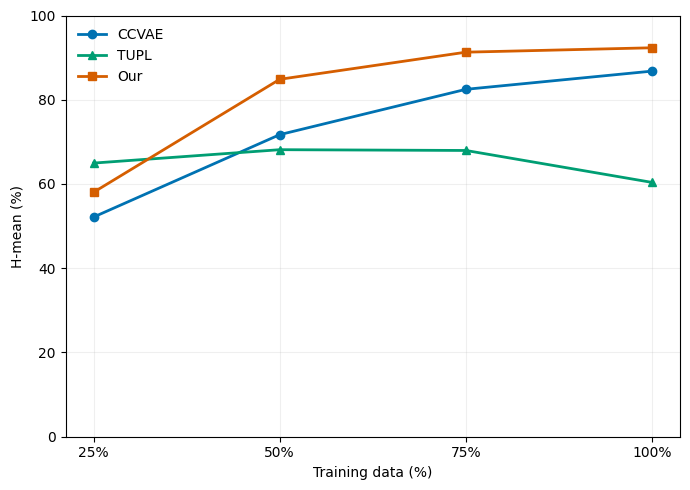

In [27]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

saved_results = json.loads(Path("./result/json/actionStyle_v3.json").read_text())
percentages = [25, 50, 75, 100]
styles = ["angry", "childlike", "depressed", "neutral", "old", "proud", "strutting"]

fig, ax = plt.subplots(figsize=(7, 5))
for method, label, color, marker in [
    ("CCVAE", "CCVAE", "#0072B2", "o"),
    ("TUPL", "TUPL", "#009E73", "^"),
    ("our_GRE", "Our", "#D55E00", "s"),
]:
    accuracy = []
    for percent in percentages:
        scores = [
            float(saved_results[method][f"all_but_{style}_{percent} -> {style}"]
                  .split("H-mean:")[1].split("±")[0])
            for style in styles
        ]
        accuracy.append(sum(scores) / len(scores))
    ax.plot(percentages, accuracy, label=label, color=color, marker=marker, linewidth=2)

ax.set_xticks(percentages, [f"{p}%" for p in percentages])
ax.set_xlabel("Training data (%)")
ax.set_ylabel("H-mean (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
Path("./result/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("./result/figures/actionStyle_v3_training_size.png", dpi=200)
plt.show()


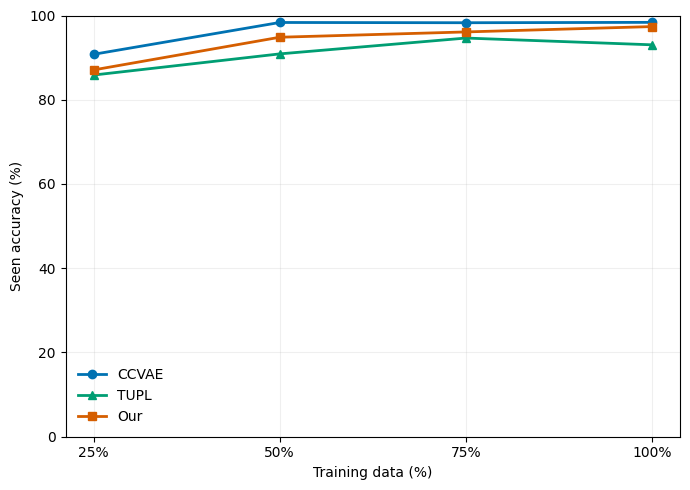

In [28]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

saved_results = json.loads(Path("./result/json/actionStyle_v3.json").read_text())
percentages = [25, 50, 75, 100]
styles = ["angry", "childlike", "depressed", "neutral", "old", "proud", "strutting"]

fig, ax = plt.subplots(figsize=(7, 5))
for method, label, color, marker in [
    ("CCVAE", "CCVAE", "#0072B2", "o"),
    ("TUPL", "TUPL", "#009E73", "^"),
    ("our_GRE", "Our", "#D55E00", "s"),
]:
    accuracy = []
    for percent in percentages:
        scores = [
            float(saved_results[method][f"all_but_{style}_{percent} -> {style}"]
                  .split("Seen:")[1].split("±")[0])
            for style in styles
        ]
        accuracy.append(sum(scores) / len(scores))
    ax.plot(percentages, accuracy, label=label, color=color, marker=marker, linewidth=2)

ax.set_xticks(percentages, [f"{p}%" for p in percentages])
ax.set_xlabel("Training data (%)")
ax.set_ylabel("Seen accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
Path("./result/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("./result/figures/actionStyle_v3_training_size_seen.png", dpi=200)
plt.show()


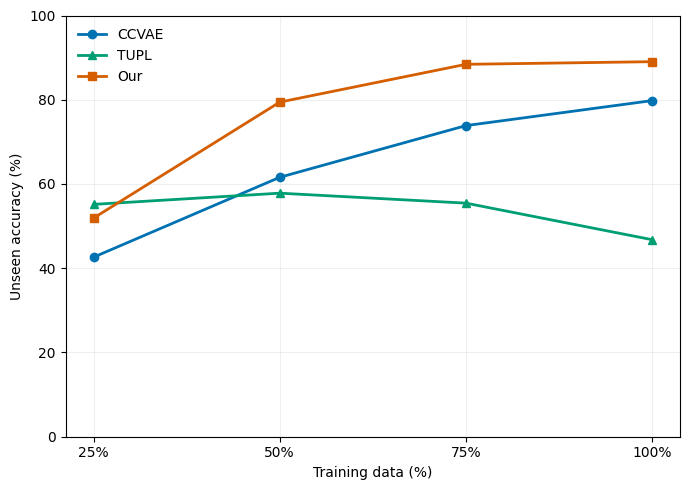

In [29]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

saved_results = json.loads(Path("./result/json/actionStyle_v3.json").read_text())
percentages = [25, 50, 75, 100]
styles = ["angry", "childlike", "depressed", "neutral", "old", "proud", "strutting"]

fig, ax = plt.subplots(figsize=(7, 5))
for method, label, color, marker in [
    ("CCVAE", "CCVAE", "#0072B2", "o"),
    ("TUPL", "TUPL", "#009E73", "^"),
    ("our_GRE", "Our", "#D55E00", "s"),
]:
    accuracy = []
    for percent in percentages:
        scores = [
            float(saved_results[method][f"all_but_{style}_{percent} -> {style}"]
                  .split("Unseen:")[1].split("±")[0])
            for style in styles
        ]
        accuracy.append(sum(scores) / len(scores))
    ax.plot(percentages, accuracy, label=label, color=color, marker=marker, linewidth=2)

ax.set_xticks(percentages, [f"{p}%" for p in percentages])
ax.set_xlabel("Training data (%)")
ax.set_ylabel("Unseen accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
Path("./result/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("./result/figures/actionStyle_v3_training_size_unseen.png", dpi=200)
plt.show()
